In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

# Le notebook se trouve dans ABSA-V2/notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
GOLD_DIR = DATA_DIR / "gold"
INTERIM_DIR = DATA_DIR / "interim"

FILES = {
    # Données brutes
    "fr_full": RAW_DIR / "df_fr_full.jsonl",
    "en_full": RAW_DIR / "df_en_full.jsonl",
    "amazon_20k": RAW_DIR / "amazon_reviews_20k.csv",

    # Artefacts V1 conservés comme baseline
    "gold_400": GOLD_DIR / "gold_standard_annote.csv",
    "gold_test_v1": GOLD_DIR / "vos_200_avis_manuels_test.csv",
    "pseudo_labels_v1": INTERIM_DIR / "pseudo_labels_fewshot.csv",
    "purified_v1": INTERIM_DIR / "dataset_20k_purifie_v2.csv",

    # Gold V2 officiel
    "gold_v2_700": GOLD_DIR / "gold_v2_700_with_provenance.csv",
    "gold_v2_dev": GOLD_DIR / "gold_v2_dev_500.csv",
    "gold_v2_test": GOLD_DIR / "gold_v2_test_200.csv",
}

for name, path in FILES.items():
    print(f"{name:15} | existe={path.exists()} | {path}")

fr_full         | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\df_fr_full.jsonl
en_full         | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\df_en_full.jsonl
amazon_20k      | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\amazon_reviews_20k.csv
gold_400        | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_standard_annote.csv
gold_test_v1    | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\vos_200_avis_manuels_test.csv
pseudo_labels_v1 | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\interim\pseudo_labels_fewshot.csv
purified_v1     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\interim\dataset_20k_purifie_v2.csv
gold_v2_700     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_v2_700_with_provenance.csv
gold_v2_dev     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_v2_dev_500.csv
gold_v2_test    | existe=True | c:\Users\

In [2]:
import pandas as pd 
gold_dev = pd.read_csv(FILES["gold_v2_dev"])
gold_dev.head

<bound method NDFrame.head of              id language                                               text  \
0    fr_0605960       fr  Trop cher\n\nBeaucoup de défaut de fabrication...   
1    fr_0200494       fr  Top : joli et facile à monter\n\nBien fini Liv...   
2    fr_0577352       fr  Très fin et se voit mal\n\nLe disque se voit a...   
3    fr_0212831       fr  Rasoir très pratique\n\nJ’ai un pull que j’aim...   
4    en_0295305       en  Satisfied\n\nI received my smiling Apple Watch...   
..          ...      ...                                                ...   
495  fr_0140384       fr  Utile\n\nReçu en parfaite état et utilisation ...   
496  fr_0382553       fr  Très résistant aux couleurs très tendances\n\n...   
497  fr_0661253       fr  Appareil reçu incomplet.\n\nA L'ATTENTION Du S...   
498  en_0034775       en  Lumberjack in your pocket\n\nHad to cut down a...   
499  en_0856221       en  Text the seller to make sure you get the item ...   

     quality    price

In [ ]:
print("shape : ", gold_dev.shape)
print("\nColonnes : ")
print(gold_dev.columns.tolist())
print("\nInformations sur le dataset : ")
print(gold_dev.info())
print("\nNombre de valeurs manquantes par colonne : ")
print(gold_dev.isna().sum())
print("\nNombre de valeurs doublons : ")
print(gold_dev.duplicated().sum())
print("\nNombre de valeurs uniques par colonne : ")
for col in gold_dev.columns:
    print(f"{col}: {gold_dev[col].nunique()}")

In [17]:
LABELS = [
    "absent",
    "négatif",
    "neutre",
    "positif",
]

ASPECTS = [
    "quality",
    "price",
    "delivery",
    "service",
]

for aspect in ASPECTS:
    count_invalid = (~gold_dev[aspect].isin(LABELS)).sum()
    print(count_invalid, "valeurs invalides pour l'aspect", aspect)
    

0 valeurs invalides pour l'aspect quality
0 valeurs invalides pour l'aspect price
0 valeurs invalides pour l'aspect delivery
0 valeurs invalides pour l'aspect service


In [22]:
print(gold_dev["language"].value_counts())
count_invalid = (~gold_dev["language"].isin(["fr", "en"])).sum()
print(count_invalid, "valeurs invalides pour la colonne language")

language
fr    250
en    250
Name: count, dtype: int64
0 valeurs invalides pour la colonne language


In [27]:
for aspect in ASPECTS:
    print(f"\n--- {aspect.upper()} ---")

    table = pd.crosstab(
        gold_dev["language"],
        gold_dev[aspect],
        margins=True,
        margins_name="Total"
    )

    print(table)


--- QUALITY ---
quality   absent  neutre  négatif  positif  Total
language                                         
en            50      34      103       63    250
fr            54      25       96       75    250
Total        104      59      199      138    500

--- PRICE ---
price     absent  neutre  négatif  positif  Total
language                                         
en           167      30       18       35    250
fr           177      20       21       32    250
Total        344      50       39       67    500

--- DELIVERY ---
delivery  absent  neutre  négatif  positif  Total
language                                         
en           179      20       38       13    250
fr           143      12       63       32    250
Total        322      32      101       45    500

--- SERVICE ---
service   absent  neutre  négatif  positif  Total
language                                         
en           204       3       23       20    250
fr           189      10       24

In [37]:
gold_dev["n_aspects_present"] = (
    (gold_dev[ASPECTS] != "absent").sum(axis=1)
)
aspect_counts = (
    gold_dev["n_aspects_present"]
    .value_counts()
    .sort_index()
)

aspect_counts

    

n_aspects_present
0     11
1    193
2    245
3     50
4      1
Name: count, dtype: int64

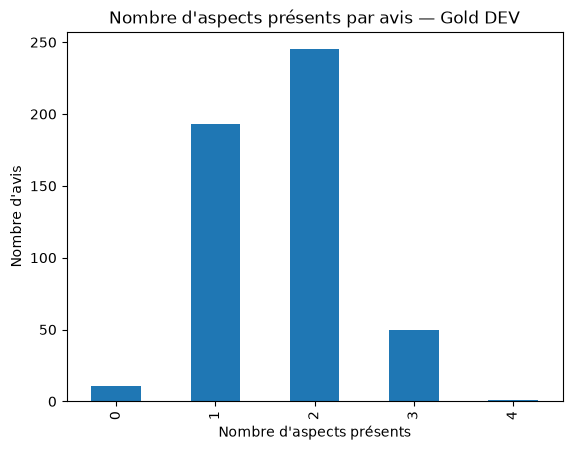

In [38]:
import matplotlib.pyplot as plt

aspect_counts.plot(kind="bar")

plt.title("Nombre d'aspects présents par avis — Gold DEV")
plt.xlabel("Nombre d'aspects présents")
plt.ylabel("Nombre d'avis")

plt.show()

In [39]:
gold_dev["text_length_words"] = (
    gold_dev["text"]
    .str.split()
    .str.len()
)

gold_dev["text_length_words"].describe()

count    500.000000
mean      42.506000
std       34.558915
min        4.000000
25%       20.000000
50%       33.000000
75%       54.000000
max      228.000000
Name: text_length_words, dtype: float64

C:\Users\youne\AppData\Local\Temp\ipykernel_24516\1679742758.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


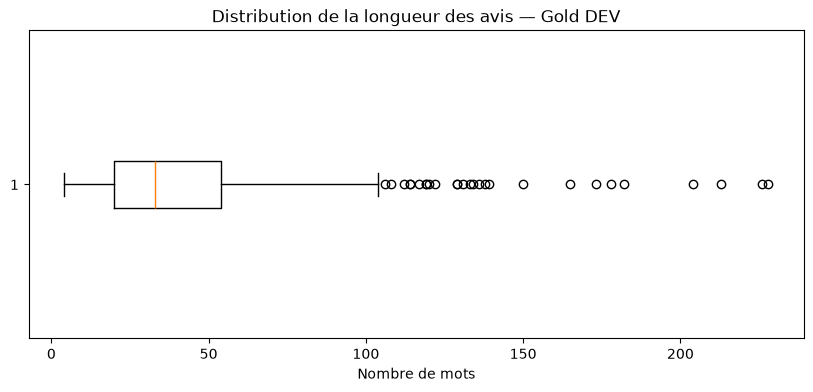

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.boxplot(
    gold_dev["text_length_words"],
    orientation="horizontal"
)

plt.title("Distribution de la longueur des avis — Gold DEV")
plt.xlabel("Nombre de mots")

plt.show()

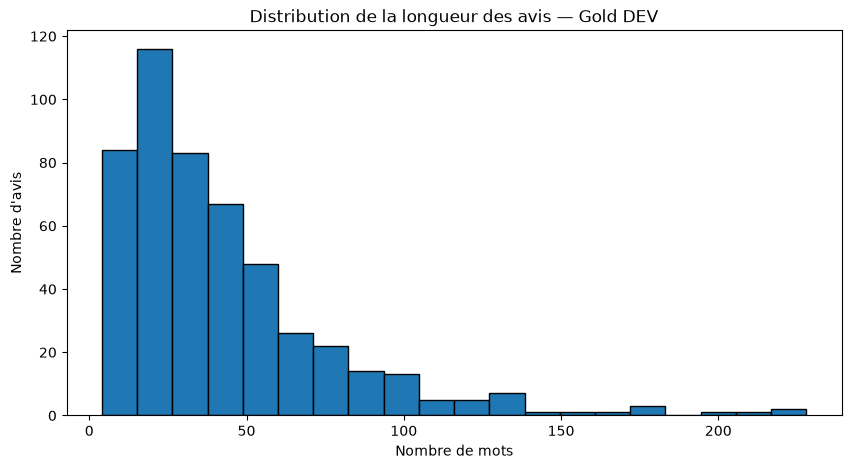

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    gold_dev["text_length_words"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution de la longueur des avis — Gold DEV")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'avis")

plt.show()

In [47]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
y_strat = pd.get_dummies(
    gold_dev[
        ["language", "quality", "price", "delivery", "service"]
    ],
    columns=["language", "quality", "price", "delivery", "service"]
    
)
mskf = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(mskf.split(gold_dev, y_strat))

In [48]:
for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_df = gold_dev.iloc[train_idx]
    val_df = gold_dev.iloc[val_idx]

    print(
        f"Fold {fold} | "
        f"train={len(train_df)} | "
        f"val={len(val_df)}"
    )

Fold 1 | train=401 | val=99
Fold 2 | train=400 | val=100
Fold 3 | train=400 | val=100
Fold 4 | train=398 | val=102
Fold 5 | train=401 | val=99


In [ ]:
for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    val_df = gold_dev.iloc[val_idx]

    print(f"\n{'=' * 50}")
    print(f"FOLD {fold} — validation ({len(val_df)} avis)")
    print(f"{'=' * 50}")

    print("\nLangues :")
    print(val_df["language"].value_counts())

    for aspect in ASPECTS:
        print(f"\n{aspect.upper()}")
        print(
            val_df[aspect]
            .value_counts()
            .reindex(LABELS, fill_value=0)
        )

In [ ]:
for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_df = gold_dev.iloc[train_idx]
    val_df = gold_dev.iloc[val_idx]

    print(f"\nFOLD {fold}")

    for aspect in ASPECTS:
        majority_class = train_df[aspect].value_counts().index[0]

        print(
            aspect,
            "→ classe majoritaire TRAIN :",
            majority_class
        )

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_df = gold_dev.iloc[train_idx]
    val_df = gold_dev.iloc[val_idx]

    for aspect in ASPECTS:
        majority_class = train_df[aspect].value_counts().index[0]

        y_true = val_df[aspect]

        y_pred = [majority_class] * len(val_df)

        accuracy = accuracy_score(y_true, y_pred)

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=LABELS,
            average="macro",
            zero_division=0
        )

        fold_results.append({
            "fold": fold,
            "aspect": aspect,
            "majority_class": majority_class,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
        })
baseline_results = pd.DataFrame(fold_results)

baseline_results

In [ ]:
baseline_summary = (
    baseline_results
    .groupby("aspect")[["accuracy", "macro_f1"]]
    .agg(["mean", "std"])
)

baseline_summary

## Conclusion E0

La baseline majoritaire confirme l'effet du déséquilibre des classes.

L'accuracy est particulièrement trompeuse pour les aspects dominés par `absent`,
notamment Service, alors que le Macro-F1 révèle l'incapacité du prédicteur
constant à reconnaître les autres classes.

Le **Macro-F1** est donc retenu comme métrique principale de comparaison pour les
expériences suivantes, avec analyse complémentaire par aspect, classe et langue.

La validation croisée multilabel stratifiée 5-fold produit des distributions
stables et devient le protocole de référence pour E0/E1.

E0 constitue désormais le plancher de comparaison pour E1.
